# ML-04 — Search Intelligence Data Contract

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Unit of analysis + time window

*One row = one what, over which dates? State it, then verify it below.*

Unit of analysis: One row represents one content item for one client on one day.
Time window: I will use March 2026 as the initial development window and aggregate daily performance signals when a monthly decision view is needed. I will keep the final month as a sealed test period to avoid using future information during development.

## 2. Fields: feature / label / context / excluded

*Sort every field you plan to touch into these four buckets. Excluded needs a why.*

Features:
- gsc_impressions
- gsc_clicks
- gsc_avg_position
- ga4_sessions
- sessions_organic

Label / Proxy:
- Future performance decline, measured using a future observation window after the decision point.

Context:
- client_has_gsc
- client_has_ga4
- gsc_data_available
- ga4_data_available
- report_date

Excluded:
I will exclude future-window performance metrics from the features because they would not be available at the decision moment and could cause data leakage. I will also exclude label-derived fields and any final decision output from the feature set.

## 3. Verify it with queries (grain, counts, missing values, windows)

*Every claim above gets a query cell here. A contract claim without a query next to it is a guess.*

Query 1: Grain verification
```
SELECT
    client_hash_id,
    content_hash_id,
    report_date,
    COUNT(*) AS row_count
FROM fact_content_daily_performance
GROUP BY
    client_hash_id,
    content_hash_id,
    report_date
HAVING COUNT(*) > 1
LIMIT 20;
```
0 output


Query 2: Row count and date window
```
SELECT
    COUNT(*) AS row_count,
    MIN(report_date) AS min_date,
    MAX(report_date) AS max_date
FROM fact_content_daily_performance
WHERE report_date >= '2026-03-01'
  AND report_date < '2026-04-01';
```
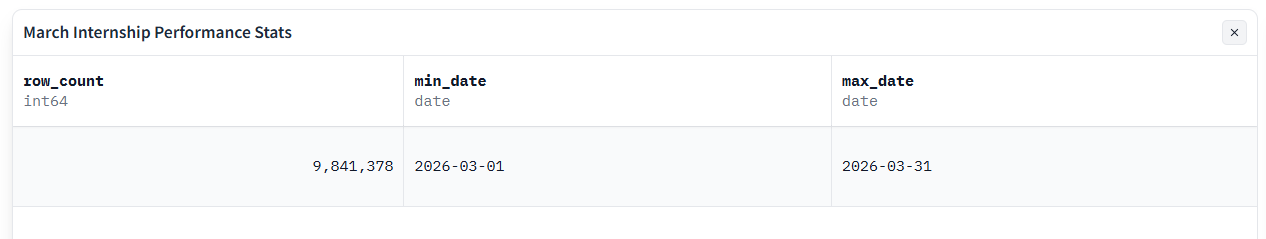

Query 3: Feature availability / missing values
```
SELECT
    COUNT(*) AS total_rows,
    COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) AS gsc_available_rows,
    COUNT(*) FILTER (WHERE ga4_data_available IS TRUE) AS ga4_available_rows
FROM fact_content_daily_performance
WHERE report_date >= '2026-03-01'
  AND report_date < '2026-04-01';
```
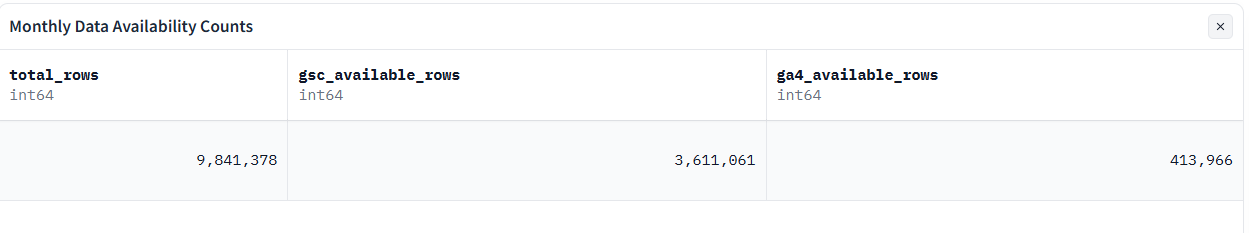

## 4. Data limits

*What can this data never tell you? Unbalanced history, GSC-only early rows, window overlaps.*

Data limitations: This data cannot fully explain why a content item's performance changed because it does not capture every external factor that may influence search and traffic outcomes. The data also has unbalanced history across clients, and some early rows may contain only Google Search Console signals. Therefore, the results should be treated as observed and directional decision support rather than causal proof.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.